# Group Patients into Meaningful Lifestyle Based Segments (K-Means)

## 1) Import Libraries

In [29]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

import os
os.getcwd()

'C:\\Users\\milen\\Downloads'

## 2) Load Dataset

In [30]:
df=pd.read_csv("Diabetes_and_LifeStyle_Dataset_.csv")

#Clean column names by removing leading and trailing spaces
df.columns=df.columns.str.strip()

df.head()

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


## 3) Select Relevant Lifestyle Features

In [40]:
features=['bmi','physical_activity_minutes_per_week','sleep_hours_per_day','alcohol_consumption_per_week','screen_time_hours_per_day'] #smoking_status was not included since it is a catergorical and non numeric variable
X=df[features]

## 4) Handle Missing Values

In [32]:
X=X.dropna() # removes all rows in X (dataset features) that contain missing values

## 5) Scale Data

In [33]:
scaler=StandardScaler() #scaling so that mean=0 and SD=1
X_scaled=scaler.fit_transform(X)

Scaling data helps so that data is less skewed by levelling the playing field of different feature values. Scaling also helps your algo run faster and more efficiently.

## 6) Create Elbow Graph to Confirm k=3 is Most Likely

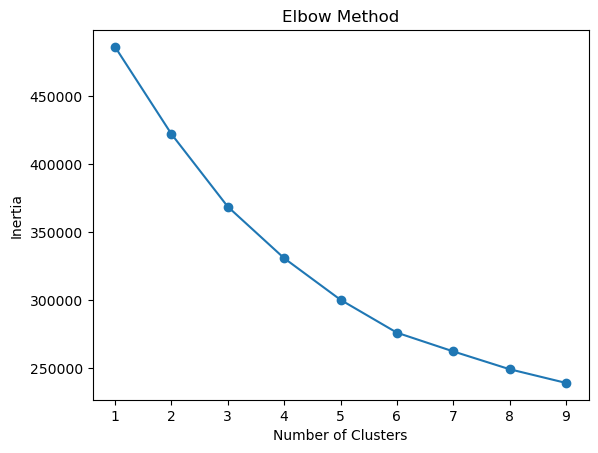

In [34]:
inertia=[]

for k in range(1, 10):
    km=KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## 7) Apply K-Means (k=3)

In [35]:
kmeans=KMeans(n_clusters=3, random_state=42)
clusters=kmeans.fit_predict(X_scaled)

df.loc[X.index, 'lifestyle_group']=clusters

## 8) Analyze Clusters

In [36]:
cluster_summary=df.groupby('lifestyle_group')[features].mean()
cluster_summary

,bmi,physical_activity_minutes_per_week,sleep_hours_per_day,alcohol_consumption_per_week,screen_time_hours_per_day
lifestyle_group,,,,,
0.0,24.345332,245.266287,6.977604,1.732101,6.005064
1.0,26.006594,82.481672,7.004122,1.180528,5.986140
2.0,25.816998,94.210374,7.000504,3.743641,6.011467


## 9) Interpret Clusters

## 10) Visualize Clusters

### Pairplot

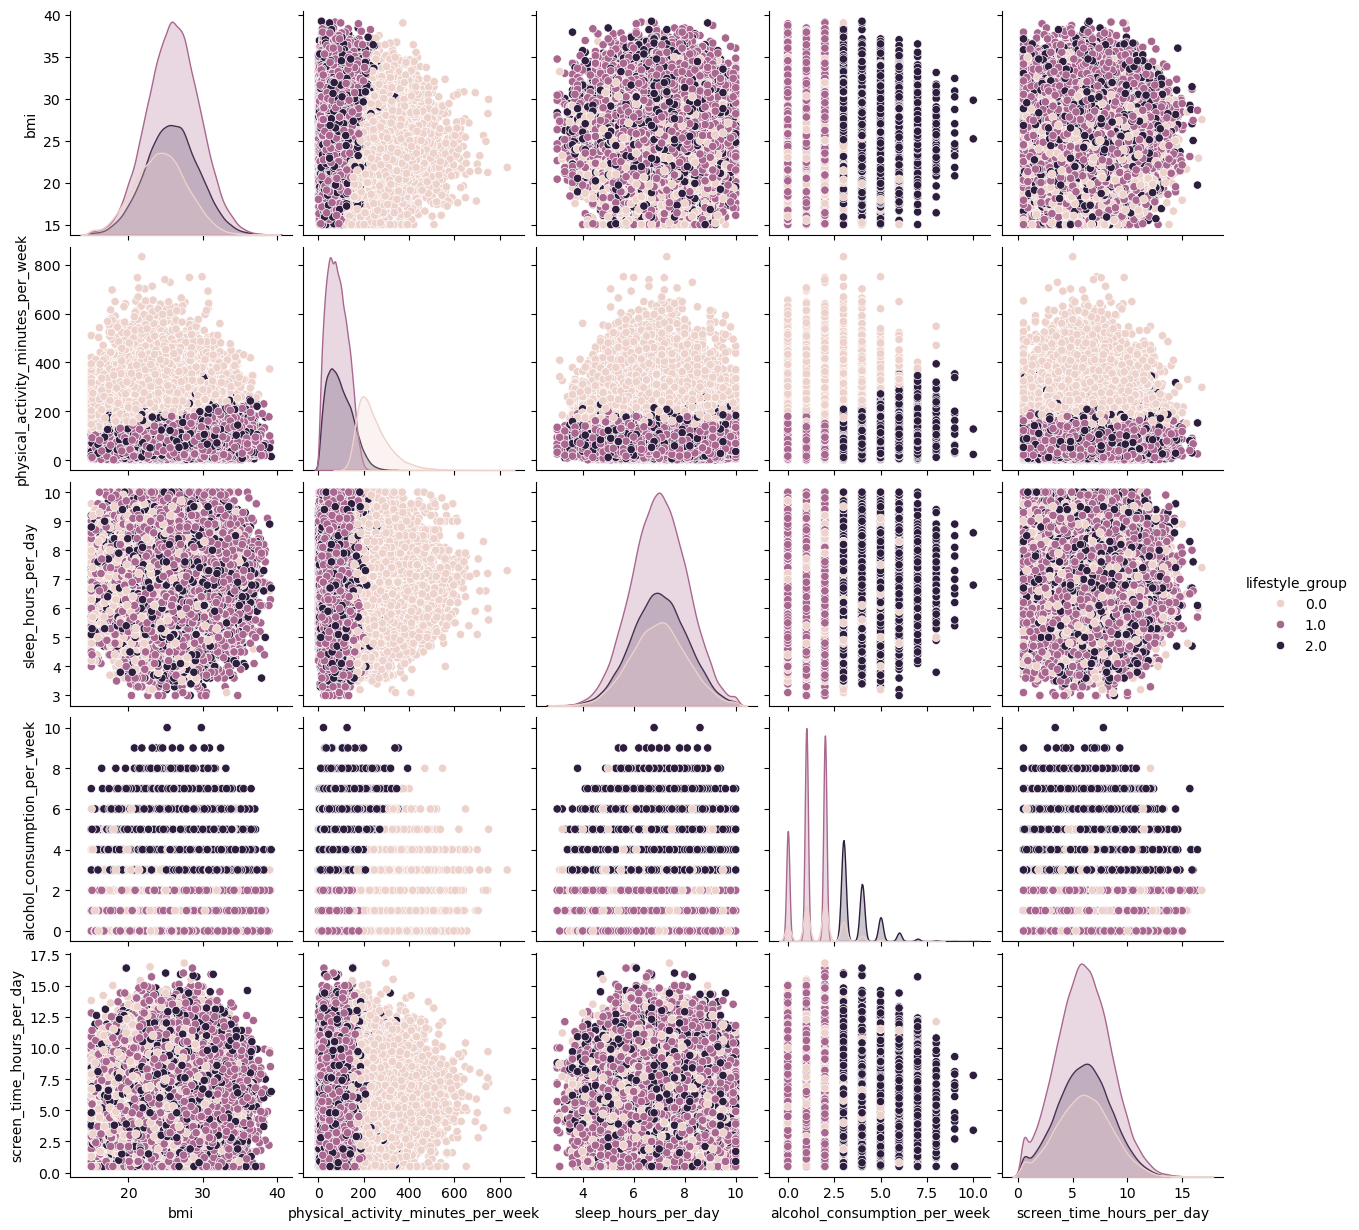

In [37]:
sns.pairplot(df, vars=features, hue='lifestyle_group')
plt.show()

### 2D Visualization (PCA)

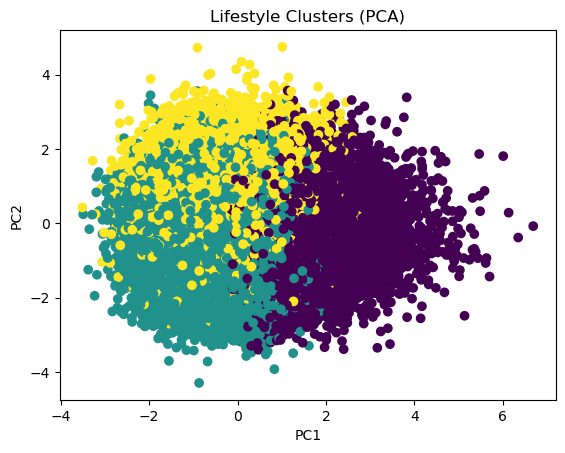

In [38]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:, 1], c=clusters)
plt.title("Lifestyle Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

### Save Results

In [39]:
df.to_csv("clustered_lifestyle_data.csv", index=False)